In [1]:
# Import necessary libraries
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pympler import asizeof
from collections import defaultdict

# Compatibility aliases for loading pickles created with NumPy 2.x
import numpy.core
import numpy.core.numeric
import numpy.core.multiarray
import numpy.core.umath

sys.modules["numpy._core"] = numpy.core
sys.modules["numpy._core.numeric"] = numpy.core.numeric
sys.modules["numpy._core.multiarray"] = numpy.core.multiarray
sys.modules["numpy._core.umath"] = numpy.core.umath 

In [2]:
# Load the battery data from the pickle file
bat_df = pd.read_pickle("../data/bat_df.pkl")

In [3]:
# Verify the structure of the DataFrame
top_level_sizes = []

for col in bat_df.columns:
    total_size = 0
    non_null_count = 0

    for item in bat_df[col]:
        if item is not None:
            non_null_count += 1
            total_size += asizeof.asizeof(item)

    top_level_sizes.append({
        "column": col,
        "dtype": str(bat_df[col].dtype),
        "non_null_count": non_null_count,
        "estimated_size_MB": total_size / 1024**2
    })

top_level_size_df = pd.DataFrame(top_level_sizes)
top_level_size_df = top_level_size_df.sort_values("estimated_size_MB", ascending=False)

top_level_size_df

,column,dtype,non_null_count,estimated_size_MB
3,cycles,object,124,14031.033333
4,IR,object,124,1.577988
5,QC,object,124,1.577988
6,QD,object,124,1.577988
7,Tavg,object,124,1.577988
8,Tmin,object,124,1.577988
9,Tmax,object,124,1.577988
10,chargetime,object,124,1.577988
11,cycle,object,124,1.577988
2,charge_policy,object,124,0.008141


In [4]:
# Verify the structure of the "cycles" column
cycle_field_sizes = defaultdict(lambda: {
    "count": 0,
    "estimated_size_bytes": 0,
    "raw_array_nbytes": 0,
    "dtypes": defaultdict(int),
    "shapes": defaultdict(int),
    "example_type": None
})

for battery_idx, cycles in enumerate(bat_df["cycles"]):

    for cycle_num, cycle_data in cycles.items():
        for field, value in cycle_data.items():
            cycle_field_sizes[field]["count"] += 1
            cycle_field_sizes[field]["estimated_size_bytes"] += asizeof.asizeof(value)
            cycle_field_sizes[field]["example_type"] = type(value).__name__

            if isinstance(value, np.ndarray):
                cycle_field_sizes[field]["raw_array_nbytes"] += value.nbytes
                cycle_field_sizes[field]["dtypes"][str(value.dtype)] += 1
                cycle_field_sizes[field]["shapes"][value.shape] += 1
            else:
                cycle_field_sizes[field]["dtypes"][type(value).__name__] += 1

cycle_rows = []

for field, info in cycle_field_sizes.items():
    most_common_shapes = sorted(
        info["shapes"].items(),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    cycle_rows.append({
        "cycle_field": field,
        "count": info["count"],
        "example_type": info["example_type"],
        "estimated_size_MB": info["estimated_size_bytes"] / 1024**2,
        "raw_array_nbytes_MB": info["raw_array_nbytes"] / 1024**2,
        "dtypes": dict(info["dtypes"]),
        "most_common_shapes": most_common_shapes
    })

cycle_field_size_df = pd.DataFrame(cycle_rows)
cycle_field_size_df = cycle_field_size_df.sort_values(
    "estimated_size_MB",
    ascending=False
)

cycle_field_size_df

,cycle_field,count,example_type,estimated_size_MB,raw_array_nbytes_MB,dtypes,most_common_shapes
3,Qdlin,100501,ndarray,1568.937004,766.449600,"{'uint64': 41, 'float64': 100460}","[((1000,), 100460), ((2,), 41)]"
5,Tdlin,100501,ndarray,1568.937004,766.449600,"{'uint64': 41, 'float64': 100460}","[((1000,), 100460), ((2,), 41)]"
7,dQdV,100501,ndarray,1568.937004,766.449600,"{'uint64': 41, 'float64': 100460}","[((1000,), 100460), ((2,), 41)]"
0,I,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
1,Qc,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
2,Qd,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
4,T,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
6,V,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
8,t,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."


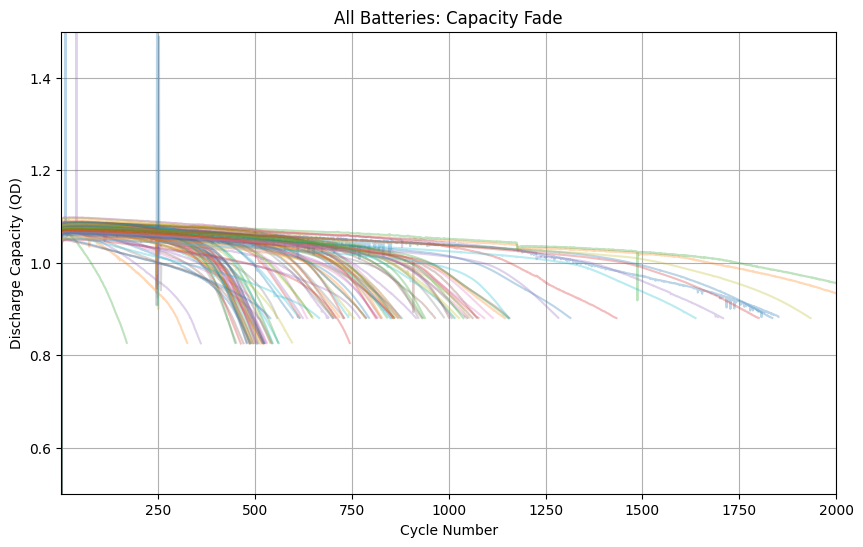

In [ ]:
# Plot the capacity fade (QD) over cycles for all batteries
plt.figure(figsize=(10, 6))
for _, row in bat_df.iterrows():
    plt.plot(row["cycle"], row["QD"], alpha=0.3)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (QD)")
plt.title("All Batteries: Capacity Fade")
plt.grid(True)
plt.xlim(1, 2000)
plt.ylim(0.5,1.5)
plt.show()

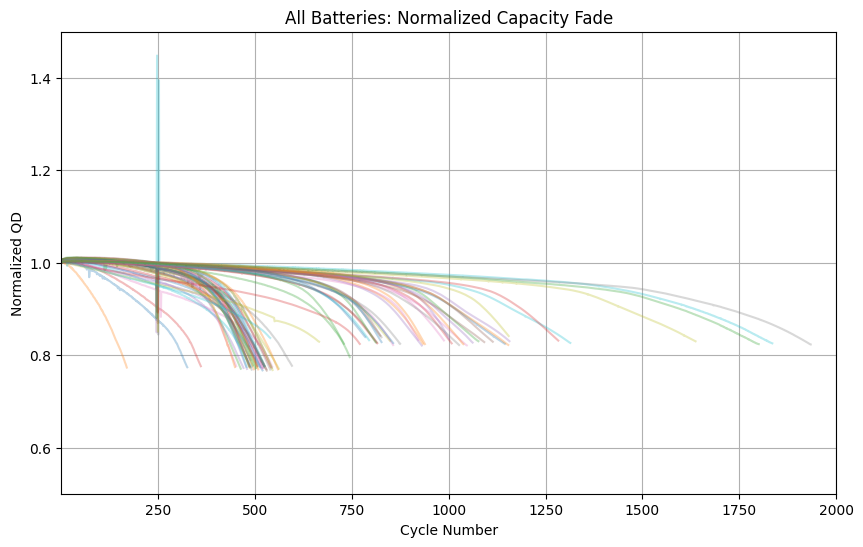

In [ ]:
# Plot the normalized capacity fade (QD/QD[0]) over cycles for all batteries
plt.figure(figsize=(10, 6))
for _, row in bat_df.iterrows():
    qd = row["QD"]
    if len(qd) > 0 and qd[0] != 0:
        plt.plot(row["cycle"], qd / qd[0], alpha=0.3)
plt.xlabel("Cycle Number")
plt.ylabel("Normalized QD")
plt.title("All Batteries: Normalized Capacity Fade")
plt.grid(True)
plt.xlim(1, 2000)
plt.ylim(0.5,1.5)
plt.show()

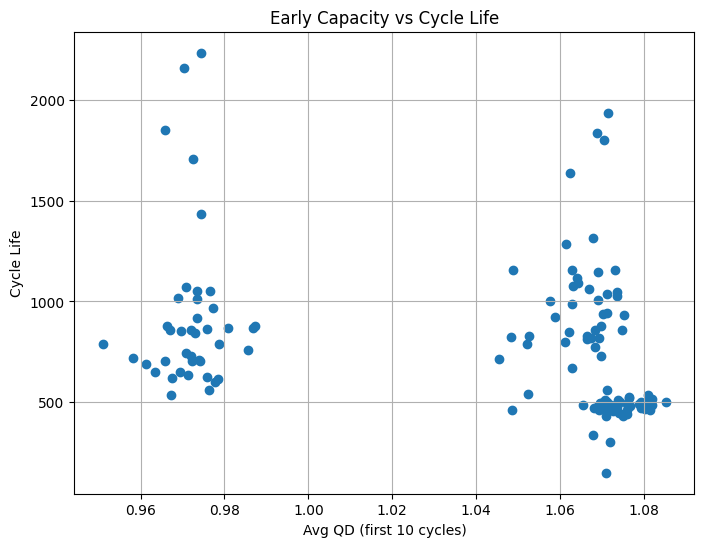

In [ ]:
# Plot early capacity (average of first 10 cycles) vs cycle life
early_qd = []
life = []

for _, row in bat_df.iterrows():
    qd = row["QD"]
    if len(qd) >= 10:
        early_qd.append(np.mean(qd[:10]))
        life.append(row["cycle_life"])

plt.figure(figsize=(8, 6))
plt.scatter(early_qd, life)
plt.xlabel("Avg QD (first 10 cycles)")
plt.ylabel("Cycle Life")
plt.title("Early Capacity vs Cycle Life")
plt.grid(True)
plt.show()

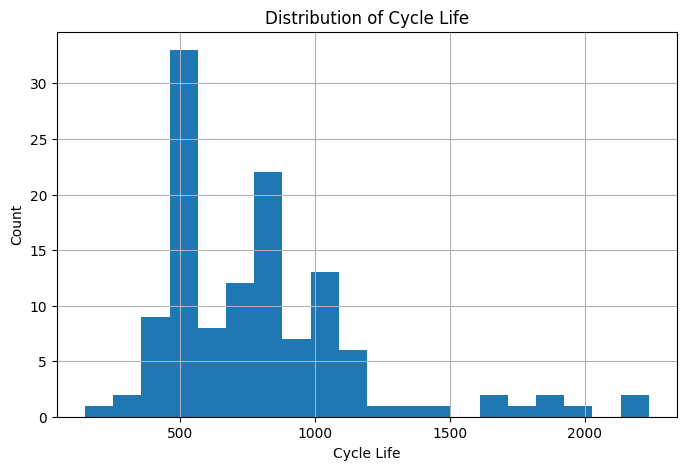

In [ ]:
# Plot the distribution of cycle life
plt.figure(figsize=(8, 5))
plt.hist(bat_df["cycle_life"], bins=20)
plt.xlabel("Cycle Life")
plt.ylabel("Count")
plt.title("Distribution of Cycle Life")
plt.grid(True)
plt.show()

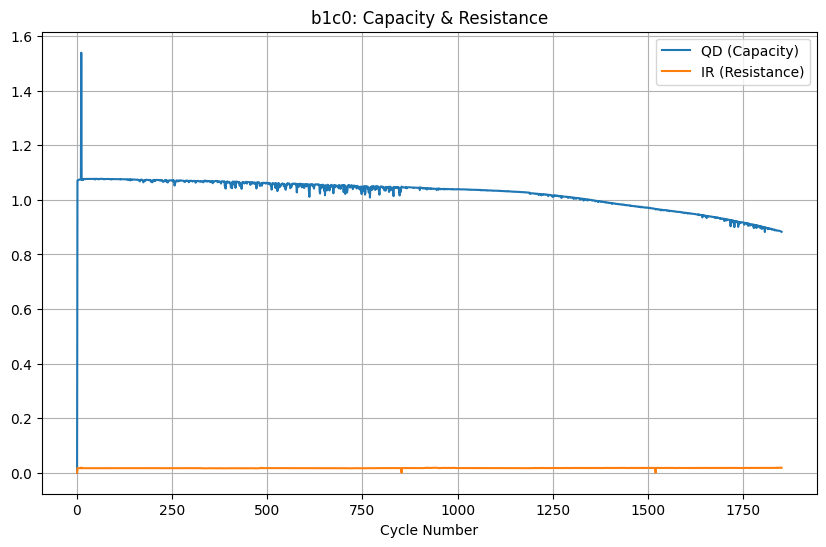

In [ ]:
# Plot capacity and resistance over all cycles for a single battery (battery 0)
battery = bat_df.iloc[0]
battery_id = battery["battery_id"]

plt.figure(figsize=(10, 6))
plt.plot(battery["cycle"], battery["QD"], label="QD (Capacity)")
plt.plot(battery["cycle"], battery["IR"], label="IR (Resistance)")
plt.xlabel("Cycle Number")
plt.title(f"{battery_id}: Capacity & Resistance")
plt.legend()
plt.grid(True)
plt.show()

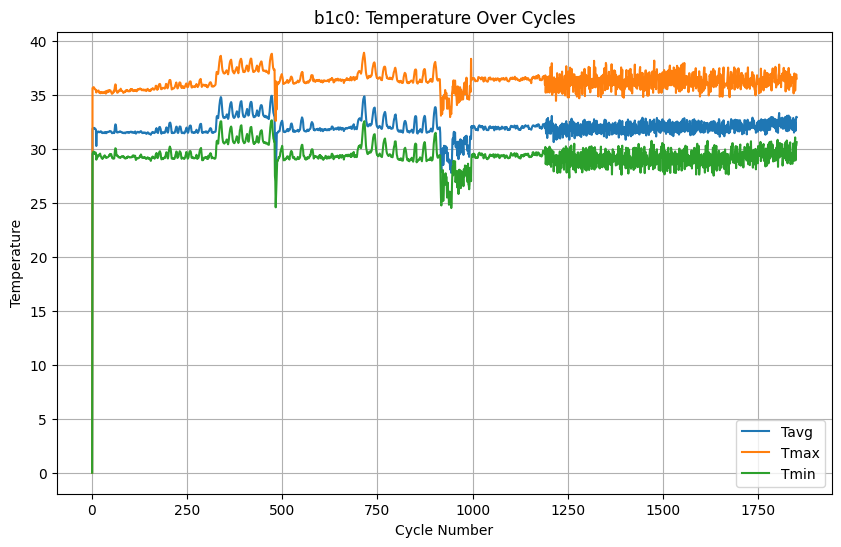

In [10]:
# Plot temperature over cycles for a single battery (battery 0)
battery = bat_df.iloc[0]
battery_id = battery["battery_id"]

plt.figure(figsize=(10, 6))
plt.plot(battery["cycle"], battery["Tavg"], label="Tavg")
plt.plot(battery["cycle"], battery["Tmax"], label="Tmax")
plt.plot(battery["cycle"], battery["Tmin"], label="Tmin")
plt.xlabel("Cycle Number")
plt.ylabel("Temperature")
plt.title(f"{battery_id}: Temperature Over Cycles")
plt.legend()
plt.grid(True)
plt.show()

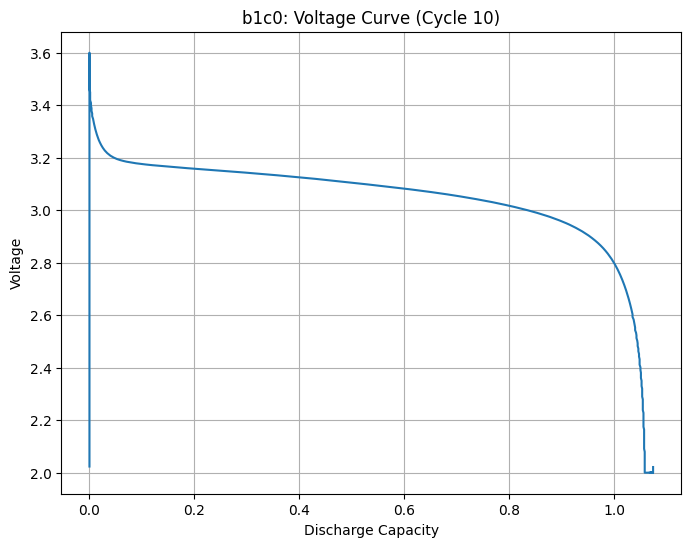

In [14]:
# Plot voltage curve (V vs Qd) for a single cycle of a single battery (battery 0, cycle 10)
battery = bat_df.iloc[0]
cycle_key = list(battery["cycles"].keys())[9]
cycle_data = battery["cycles"][cycle_key]

plt.figure(figsize=(8, 6))
plt.plot(cycle_data["Qd"], cycle_data["V"])
plt.xlabel("Discharge Capacity")
plt.ylabel("Voltage")
plt.title(f"{battery_id}: Voltage Curve (Cycle {int(cycle_key)+1})")
plt.grid(True)
plt.show()

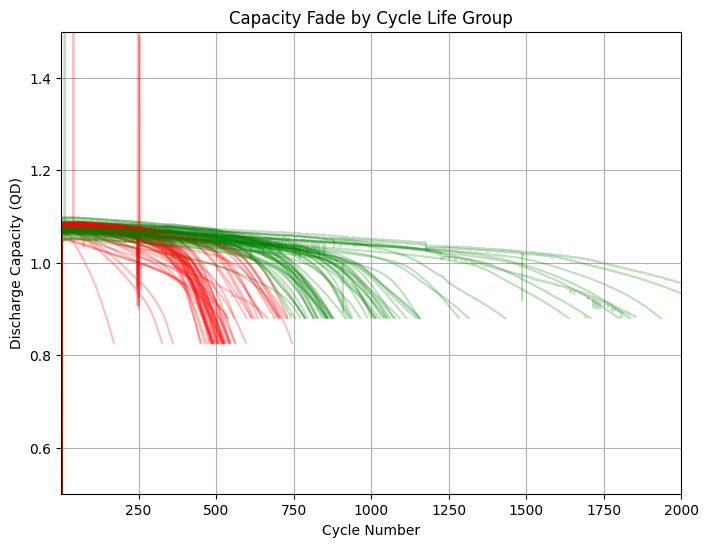

In [ ]:
# Plot capacity fade over cycles, colored by cycle life group: quickest 50% (red) vs longest 50% (green)
median_life = bat_df["cycle_life"].median()

plt.figure(figsize=(8, 6))

for i, (_, row) in enumerate(bat_df.iterrows()):
    is_quick_fail = row["cycle_life"] <= median_life

    plt.plot(row["cycle"], row["QD"], color="red" if is_quick_fail else "green", alpha=0.25)

plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (QD)")
plt.title("Capacity Fade by Cycle Life Group")
plt.grid(True)
plt.xlim(1, 2000)
plt.ylim(0.5, 1.5)
plt.show()

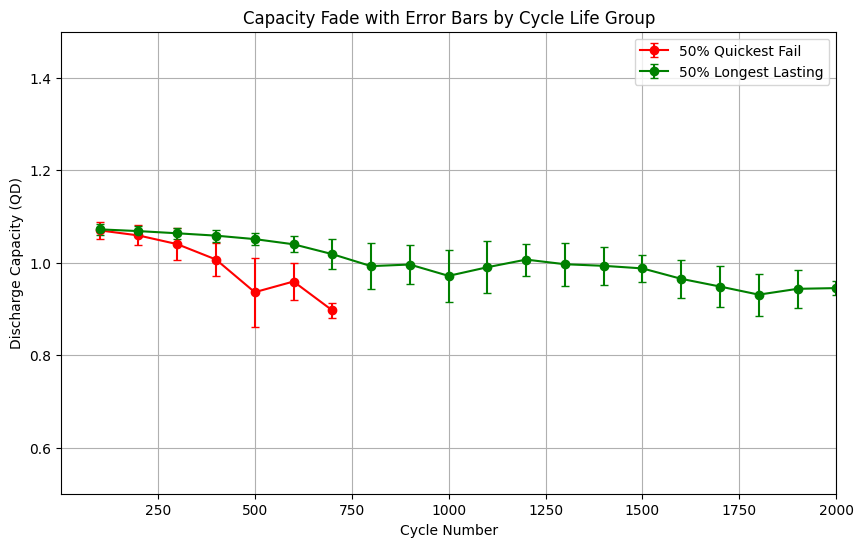

In [21]:
# Plot capacity fade with error bars for the two groups: quickest 50% (red) vs longest 50% (green)
median_life = bat_df["cycle_life"].median()

# Compute mean and std of QD at each cycle for each group
def group_stats(df, step=100):
    data = []

    for _, row in df.iterrows():
        cycles = row["cycle"]
        qd = row["QD"]

        data.append(pd.DataFrame({"cycle": cycles[cycles % step == 0], "QD": qd[cycles % step == 0]}))

    data = pd.concat(data)
    return data.groupby("cycle")["QD"].agg(["mean", "std"]).reset_index()

groups = [
    (bat_df[bat_df["cycle_life"] <= median_life], "red", "50% Quickest Fail"),
    (bat_df[bat_df["cycle_life"] > median_life], "green", "50% Longest Lasting")
]

plt.figure(figsize=(10, 6))

for df, color, label in groups:
    stats = group_stats(df)
    plt.errorbar(stats["cycle"], stats["mean"], yerr=stats["std"], color=color, marker="o", capsize=3, label=label)

plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (QD)")
plt.title("Capacity Fade with Error Bars by Cycle Life Group")
plt.grid(True)
plt.xlim(1, 2000)
plt.ylim(0.5, 1.5)
plt.legend()
plt.show()

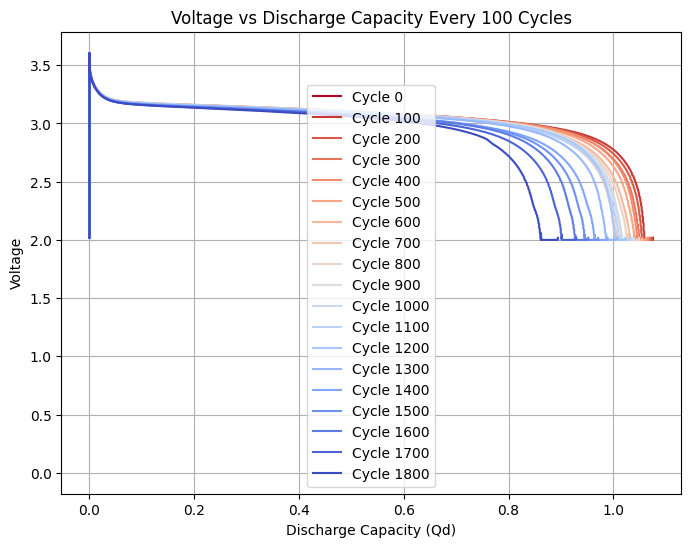

In [ ]:
# Plot voltage curve (V vs Qd) for every 100 cycles of a single battery (battery 0)
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

cycle_keys = list(battery["cycles"].keys())[::100]
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_keys)))

for key, color in zip(cycle_keys, colors):
    cd = battery["cycles"][key]

    plt.plot(cd["Qd"], cd["V"], color=color, label=f"Cycle {key}")

plt.xlabel("Discharge Capacity (Qd)")
plt.ylabel("Voltage")
plt.title("Voltage vs Discharge Capacity Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

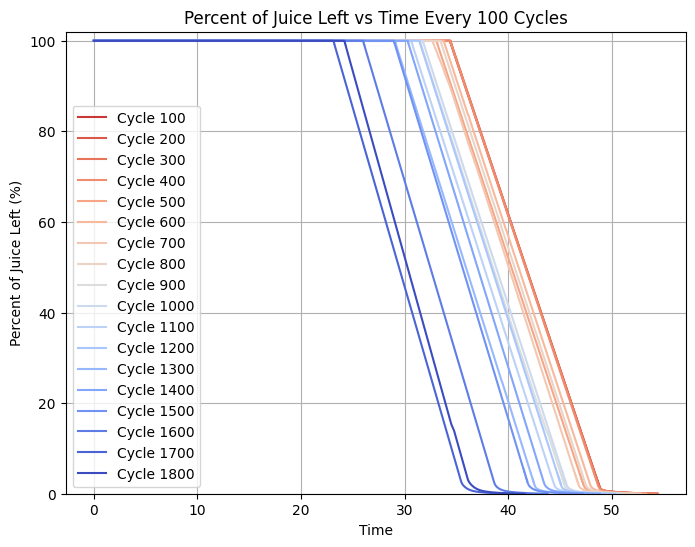

In [28]:
# Plot % discharge capacity left vs time for every 100 cycles of a single battery (battery 0)
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

cycle_keys = list(battery["cycles"].keys())[::100]
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_keys)))

for key, color in zip(cycle_keys, colors):
    cd = battery["cycles"][key]

    Qd = cd["Qd"].astype(float)
    t = cd["t"].astype(float)

    if len(Qd) == 0 or np.nanmax(Qd) == 0:
        continue

    percent_left = 100 * (1 - Qd / np.nanmax(Qd))

    plt.plot(t, percent_left, color=color, label=f"Cycle {key}")

plt.xlabel("Time")
plt.ylabel("Percent of Juice Left (%)")
plt.ylim(0, 102)
plt.title("Percent of Juice Left vs Time Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

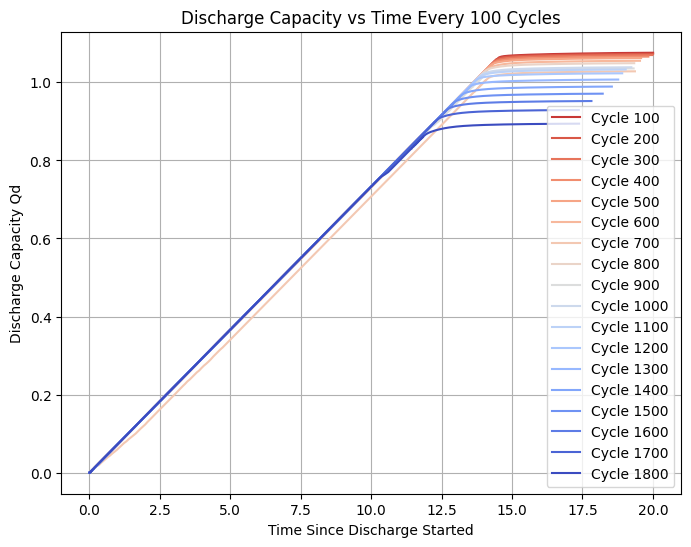

In [ ]:
# Plot discharge capacity (Qd) vs time for every 100 cycles of a single battery (battery 0)
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

cycle_keys = list(battery["cycles"].keys())[::100]
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_keys)))

for key, color in zip(cycle_keys, colors):
    cd = battery["cycles"][key]

    Qd = cd["Qd"].astype(float)
    t = cd["t"].astype(float)
    I = cd["I"].astype(float)

    discharge = I < -1e-3

    if not np.any(discharge):
        continue

    Qd = Qd[discharge]
    t = t[discharge]

    plt.plot(t - t[0], Qd - Qd[0], color=color, label=f"Cycle {key}")

plt.xlabel("Time Since Discharge Started")
plt.ylabel("Discharge Capacity Qd")
plt.title("Discharge Capacity vs Time Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

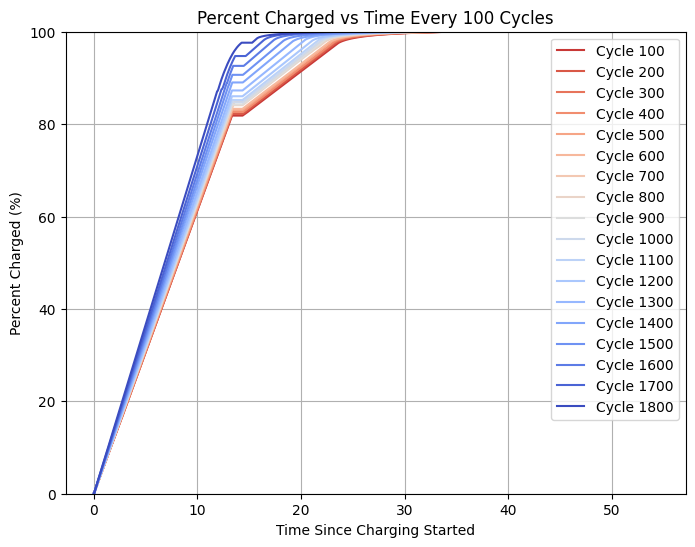

In [ ]:
# Plot percent battery charged vs time for every 100 cycles of a single battery (battery 0)
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

cycle_keys = list(battery["cycles"].keys())[::100]
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_keys)))

for key, color in zip(cycle_keys, colors):
    cd = battery["cycles"][key]

    Qc = cd["Qc"].astype(float)
    t = cd["t"].astype(float)

    charging = Qc > 0

    if not np.any(charging):
        continue

    Qc = Qc[charging]
    t = t[charging]

    percent_charged = 100 * Qc / np.nanmax(Qc)

    plt.plot(t - t[0], percent_charged, color=color, label=f"Cycle {key}")

plt.xlabel("Time Since Charging Started")
plt.ylabel("Percent Charged (%)")
plt.ylim(0, 100)
plt.title("Percent Charged vs Time Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

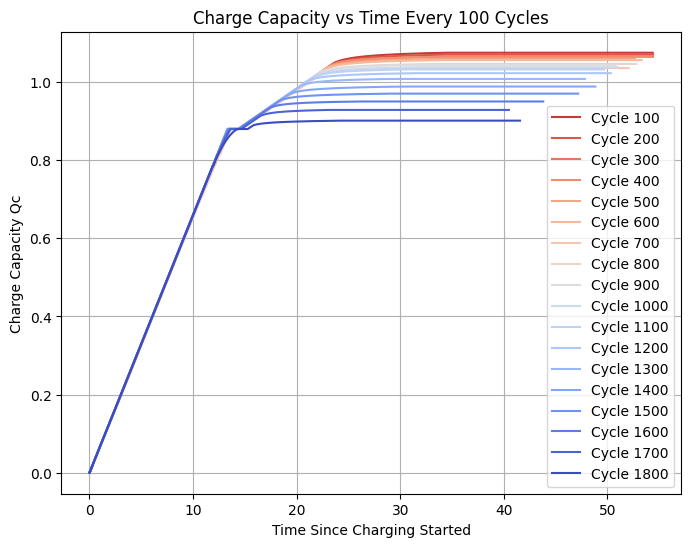

In [31]:
# Plot charge capacity (Qc) vs time for every 100 cycles of a single battery (battery 0)
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

cycle_keys = list(battery["cycles"].keys())[::100]
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_keys)))

for key, color in zip(cycle_keys, colors):
    cd = battery["cycles"][key]

    Qc = cd["Qc"].astype(float)
    t = cd["t"].astype(float)

    charging = Qc > 0

    if not np.any(charging):
        continue

    Qc = Qc[charging]
    t = t[charging]

    plt.plot(t - t[0], Qc, color=color, label=f"Cycle {key}")

plt.xlabel("Time Since Charging Started")
plt.ylabel("Charge Capacity Qc")
plt.title("Charge Capacity vs Time Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

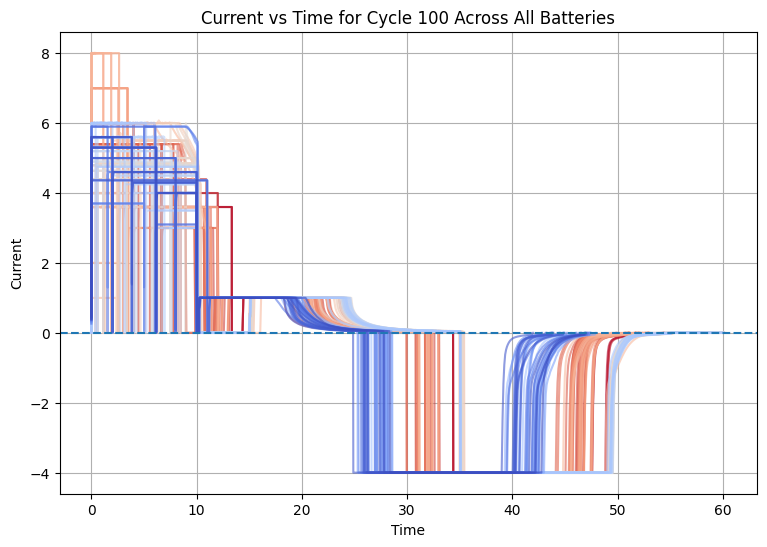

In [ ]:
# Plot current (I) vs time for a specific cycle (100) across all batteries
cycle_to_plot = "100"

plt.figure(figsize=(9, 6))

colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(bat_df)))

for color, (_, battery) in zip(colors, bat_df.iterrows()):
    cycles = battery["cycles"]

    if cycle_to_plot not in cycles:
        continue

    cd = cycles[cycle_to_plot]

    t = cd["t"].astype(float)
    I = cd["I"].astype(float)

    plt.plot(t, I, color=color, alpha=0.6)

plt.axhline(0, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Current")
plt.title(f"Current vs Time for Cycle {cycle_to_plot} Across All Batteries")
plt.grid(True)
plt.show()

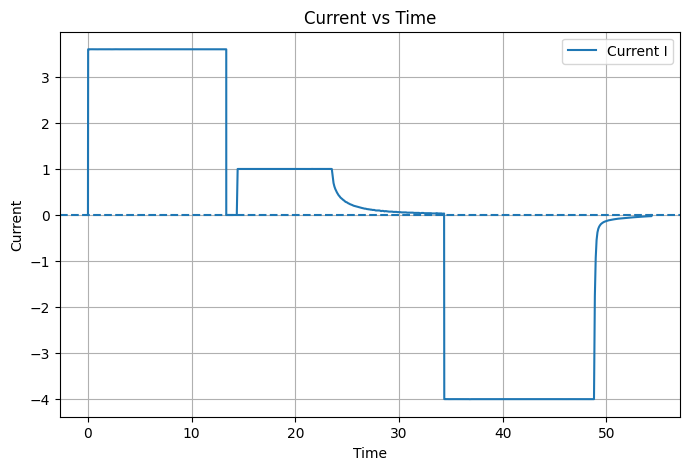

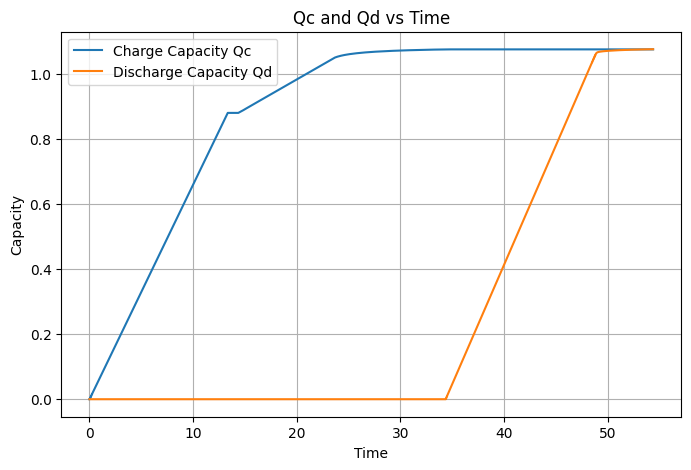

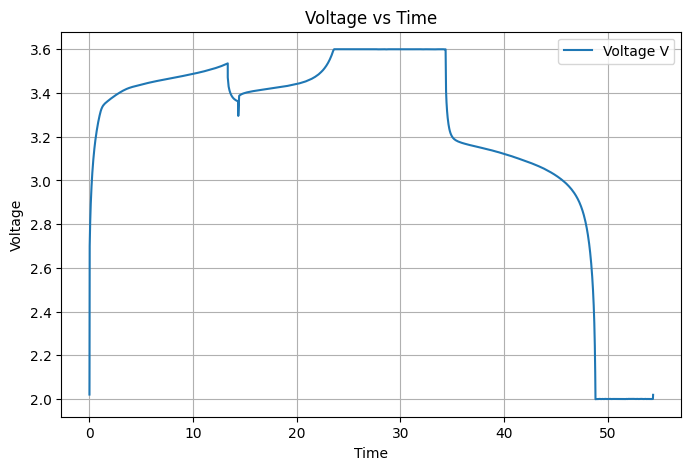

In [33]:
# Plot current, charge capacity, discharge capacity, and voltage vs time for a specific cycle (100) of a single battery (battery 0)
battery = bat_df.iloc[0]
cd = battery["cycles"]["100"]

t = cd["t"].astype(float)
I = cd["I"].astype(float)
Qc = cd["Qc"].astype(float)
Qd = cd["Qd"].astype(float)
V = cd["V"].astype(float)

plt.figure(figsize=(8, 5))
plt.plot(t, I, label="Current I")
plt.axhline(0, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Current")
plt.title("Current vs Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t, Qc, label="Charge Capacity Qc")
plt.plot(t, Qd, label="Discharge Capacity Qd")
plt.xlabel("Time")
plt.ylabel("Capacity")
plt.title("Qc and Qd vs Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t, V, label="Voltage V")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Voltage vs Time")
plt.grid(True)
plt.legend()
plt.show()

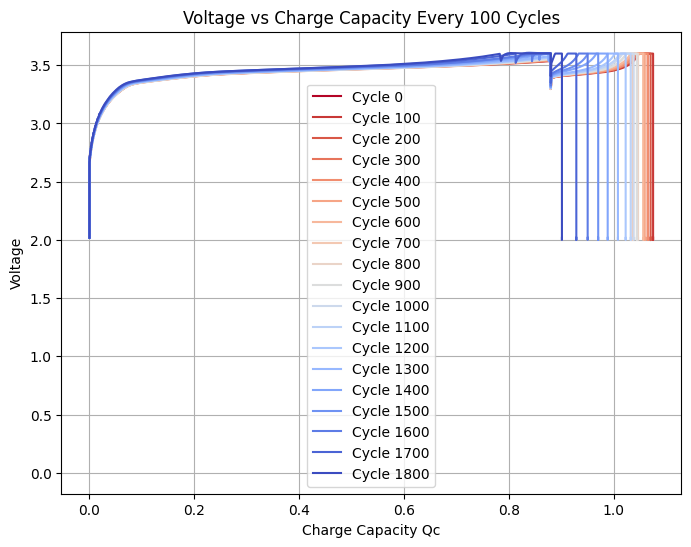

In [34]:
# Plot voltage curve (V vs Qc) for every 100 cycles of a single battery (battery 0)
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

cycle_keys = list(battery["cycles"].keys())[::100]
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_keys)))

for key, color in zip(cycle_keys, colors):
    cd = battery["cycles"][key]

    plt.plot(cd["Qc"], cd["V"], color=color, label=f"Cycle {key}")

plt.xlabel("Charge Capacity Qc")
plt.ylabel("Voltage")
plt.title("Voltage vs Charge Capacity Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

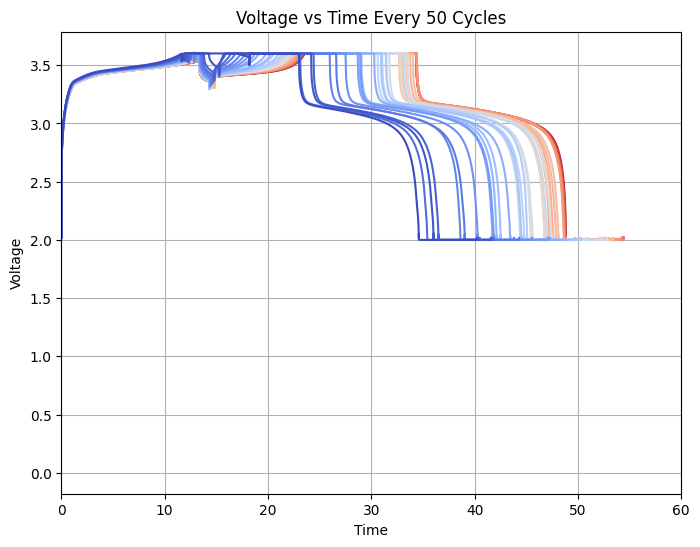

In [35]:
# Plot voltage curve (V vs time) for every 50 cycles of a single battery (battery 0)
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

cycle_keys = list(battery["cycles"].keys())[::50]
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_keys)))

for key, color in zip(cycle_keys, colors):
    cd = battery["cycles"][key]

    plt.plot(cd["t"], cd["V"], color=color, label=f"Cycle {key}")

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.xlim(0, 60)
plt.title("Voltage vs Time Every 50 Cycles")
plt.grid(True)
plt.show()